## Task 1 – Data Loading & Exploration

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_excel("../Dataset/food_delivery_analytics_3000.xlsx")
df.head()

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate
0,1,1229,Biryani House,Pizza,1,465.61,465.61,57,1,Delhi,UPI,2024-05-05
1,2,1224,Healthy Bowl,Wrap,4,96.53,386.12,42,5,Chennai,Cash,2024-02-17
2,3,1604,Taco Town,Salad,5,298.15,1490.75,10,2,Mumbai,Card,2024-08-17
3,4,1105,Pizza Point,Taco,2,191.96,383.92,34,1,Hyderabad,Card,2024-06-21
4,5,1550,Pizza Point,Wrap,3,499.71,1499.13,34,1,Delhi,Card,2024-08-23


In [11]:
df.tail()

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate
2995,2996,1024,Sushi Spot,Sandwich,5,561.70,2808.50,24,3,Mumbai,Cash,2024-04-24
2996,2997,1792,Pizza Point,Burger,2,321.62,643.24,52,2,Chennai,UPI,2024-10-26
2997,2998,1738,Sushi Spot,Wrap,4,210.30,841.20,48,5,Chennai,Card,2024-05-02
2998,2999,1505,Pasta Place,Pasta,5,248.04,1240.20,47,5,Hyderabad,Cash,2024-06-25
2999,3000,1590,Burger Hub,Burger,5,474.97,2374.85,36,5,Mumbai,Cash,2024-04-05


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 3000
Number of columns: 12
Dataset shape: (3000, 12)


In [13]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['OrderID', 'CustomerID', 'Restaurant', 'FoodItem', 'Quantity', 'OrderValue', 'TotalAmount', 'DeliveryTime_Minutes', 'CustomerRating', 'City', 'PaymentMethod', 'OrderDate']


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OrderID               3000 non-null   int64  
 1   CustomerID            3000 non-null   int64  
 2   Restaurant            3000 non-null   str    
 3   FoodItem              3000 non-null   str    
 4   Quantity              3000 non-null   int64  
 5   OrderValue            3000 non-null   float64
 6   TotalAmount           3000 non-null   float64
 7   DeliveryTime_Minutes  3000 non-null   int64  
 8   CustomerRating        3000 non-null   int64  
 9   City                  3000 non-null   str    
 10  PaymentMethod         3000 non-null   str    
 11  OrderDate             3000 non-null   str    
dtypes: float64(2), int64(5), str(5)
memory usage: 281.4 KB


In [15]:
print(df.dtypes)

OrderID                   int64
CustomerID                int64
Restaurant                  str
FoodItem                    str
Quantity                  int64
OrderValue              float64
TotalAmount             float64
DeliveryTime_Minutes      int64
CustomerRating            int64
City                        str
PaymentMethod               str
OrderDate                   str
dtype: object


In [16]:
df.describe(include="all")

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate
count,3000.000000,3000.000000,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000,3000
unique,NaN,NaN,10,10,NaN,NaN,NaN,NaN,NaN,5,3,364
top,NaN,NaN,Healthy Bowl,Wrap,NaN,NaN,NaN,NaN,NaN,Delhi,UPI,2024-07-10
freq,NaN,NaN,328,332,NaN,NaN,NaN,NaN,NaN,629,1050,19
mean,1500.500000,1397.573000,NaN,NaN,2.994333,338.074453,1009.472437,34.916333,3.002333,NaN,NaN,NaN
std,866.169729,233.609663,NaN,NaN,1.421141,149.676468,680.124564,14.943285,1.405342,NaN,NaN,NaN
min,1.000000,1001.000000,NaN,NaN,1.000000,80.050000,80.050000,10.000000,1.000000,NaN,NaN,NaN
25%,750.750000,1187.000000,NaN,NaN,2.000000,209.707500,458.070000,22.000000,2.000000,NaN,NaN,NaN
50%,1500.500000,1392.500000,NaN,NaN,3.000000,335.030000,853.350000,35.000000,3.000000,NaN,NaN,NaN
75%,2250.250000,1604.000000,NaN,NaN,4.000000,467.722500,1465.052500,48.000000,4.000000,NaN,NaN,NaN


In [17]:
print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
OrderID                 3000
CustomerID               784
Restaurant                10
FoodItem                  10
Quantity                   5
OrderValue              2923
TotalAmount             2966
DeliveryTime_Minutes      51
CustomerRating             5
City                       5
PaymentMethod              3
OrderDate                364
dtype: int64


In [18]:
total_orders = df["OrderID"].nunique()
print("Total Orders:", total_orders)
unique_customers = df["CustomerID"].nunique()
print("Unique Customers:", unique_customers)
unique_restaurants = df["Restaurant"].nunique()
print("Unique Restaurants:", unique_restaurants)
orders_by_city = df["City"].value_counts()
print(orders_by_city)

Total Orders: 3000
Unique Customers: 784
Unique Restaurants: 10
City
Delhi        629
Mumbai       619
Chennai      595
Hyderabad    594
Bangalore    563
Name: count, dtype: int64


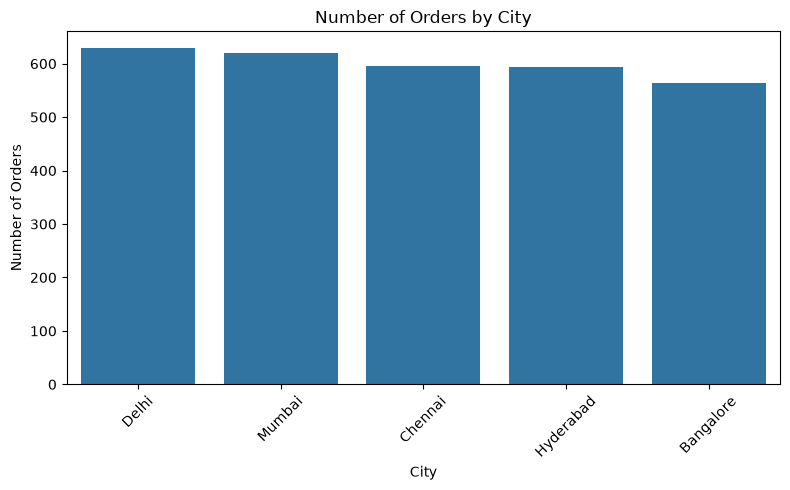

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=orders_by_city.index,
    y=orders_by_city.values
)
plt.title("Number of Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
print("Restaurant Distribution:")
print(df["Restaurant"].value_counts())

Restaurant Distribution:
Restaurant
Healthy Bowl     328
Pizza Point      309
Grill Master     306
Biryani House    305
Veg Express      300
Cafe Delight     297
Sushi Spot       296
Taco Town        293
Pasta Place      293
Burger Hub       273
Name: count, dtype: int64


In [21]:
print("\nFood Item Distribution:")
print(df["FoodItem"].value_counts())


Food Item Distribution:
FoodItem
Wrap        332
Biryani     332
Coffee      312
Sandwich    304
Sushi       298
Pizza       296
Salad       296
Burger      293
Taco        269
Pasta       268
Name: count, dtype: int64


In [22]:
print("\nCity Distribution:")
print(df["City"].value_counts())


City Distribution:
City
Delhi        629
Mumbai       619
Chennai      595
Hyderabad    594
Bangalore    563
Name: count, dtype: int64


In [23]:
print("\nPayment Method Distribution:")
print(df["PaymentMethod"].value_counts())


Payment Method Distribution:
PaymentMethod
UPI     1050
Cash     987
Card     963
Name: count, dtype: int64


In [24]:
print("\nCustomer Rating Distribution:")
print(df["CustomerRating"].value_counts().sort_index())


Customer Rating Distribution:
CustomerRating
1    595
2    592
3    605
4    627
5    581
Name: count, dtype: int64


## Task 2 – Data Cleaning & Preparation

In [25]:
df_clean = df.copy()
print("Original shape:", df.shape)
print("Cleaning dataframe shape:", df_clean.shape)

Original shape: (3000, 12)
Cleaning dataframe shape: (3000, 12)


In [26]:
missing_values = df_clean.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
OrderID                 0
CustomerID              0
Restaurant              0
FoodItem                0
Quantity                0
OrderValue              0
TotalAmount             0
DeliveryTime_Minutes    0
CustomerRating          0
City                    0
PaymentMethod           0
OrderDate               0
dtype: int64


In [27]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [28]:
print(df_clean["Quantity"].describe())

count    3000.000000
mean        2.994333
std         1.421141
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64


In [29]:
invalid_quantity = df_clean[
    (df_clean["Quantity"] <= 0) |
    (df_clean["Quantity"].isnull())
]

print("Invalid Quantity records:", len(invalid_quantity))

Invalid Quantity records: 0


In [30]:
print("Unique Quantity values:")
print(sorted(df_clean["Quantity"].unique()))

Unique Quantity values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [31]:
print(df_clean["OrderValue"].describe())

count    3000.000000
mean      338.074453
std       149.676468
min        80.050000
25%       209.707500
50%       335.030000
75%       467.722500
max       599.990000
Name: OrderValue, dtype: float64


In [32]:
invalid_order_value = df_clean[
    (df_clean["OrderValue"] <= 0) |
    (df_clean["OrderValue"].isnull())
]

print("Invalid OrderValue records:", len(invalid_order_value))

Invalid OrderValue records: 0


In [33]:
print(df_clean["TotalAmount"].describe())

count    3000.000000
mean     1009.472437
std       680.124564
min        80.050000
25%       458.070000
50%       853.350000
75%      1465.052500
max      2997.850000
Name: TotalAmount, dtype: float64


In [34]:
invalid_total_amount = df_clean[
    (df_clean["TotalAmount"] <= 0) |
    (df_clean["TotalAmount"].isnull())
]

print("Invalid TotalAmount records:", len(invalid_total_amount))

Invalid TotalAmount records: 0


In [35]:
df_clean["CalculatedAmount"] = (
    df_clean["Quantity"] * df_clean["OrderValue"]
)

df_clean["AmountDifference"] = (
    df_clean["TotalAmount"] - df_clean["CalculatedAmount"]
)

print(df_clean["AmountDifference"].describe())

count    3.000000e+03
mean    -3.694822e-15
std      8.044450e-14
min     -4.547474e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: AmountDifference, dtype: float64


In [36]:
mismatch = df_clean[
    ~np.isclose(
        df_clean["TotalAmount"],
        df_clean["CalculatedAmount"],
        atol=0.01
    )
]

print("Amount mismatches:", len(mismatch))

Amount mismatches: 0


In [37]:
df_clean["OrderDate"] = pd.to_datetime(
    df_clean["OrderDate"],
    errors="coerce"
)
print("After conversion:")
print(df_clean["OrderDate"].dtype)

After conversion:
datetime64[us]


In [38]:
df_clean["Year"] = df_clean["OrderDate"].dt.year
df_clean[["OrderDate", "Year"]].head()

,OrderDate,Year
0,2024-05-05,2024
1,2024-02-17,2024
2,2024-08-17,2024
3,2024-06-21,2024
4,2024-08-23,2024


In [39]:
df_clean["Month"] = df_clean["OrderDate"].dt.month
df_clean[["OrderDate", "Month"]].head()

,OrderDate,Month
0,2024-05-05,5
1,2024-02-17,2
2,2024-08-17,8
3,2024-06-21,6
4,2024-08-23,8


In [40]:
df_clean["Weekday"] = df_clean["OrderDate"].dt.day_name()
df_clean[["OrderDate", "Weekday"]].head()

,OrderDate,Weekday
0,2024-05-05,Sunday
1,2024-02-17,Saturday
2,2024-08-17,Saturday
3,2024-06-21,Friday
4,2024-08-23,Friday


In [41]:
df_clean.head()

,OrderID,CustomerID,Restaurant,FoodItem,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,City,PaymentMethod,OrderDate,CalculatedAmount,AmountDifference,Year,Month,Weekday
0,1,1229,Biryani House,Pizza,1,465.61,465.61,57,1,Delhi,UPI,2024-05-05,465.61,0.000000e+00,2024,5,Sunday
1,2,1224,Healthy Bowl,Wrap,4,96.53,386.12,42,5,Chennai,Cash,2024-02-17,386.12,0.000000e+00,2024,2,Saturday
2,3,1604,Taco Town,Salad,5,298.15,1490.75,10,2,Mumbai,Card,2024-08-17,1490.75,0.000000e+00,2024,8,Saturday
3,4,1105,Pizza Point,Taco,2,191.96,383.92,34,1,Hyderabad,Card,2024-06-21,383.92,0.000000e+00,2024,6,Friday
4,5,1550,Pizza Point,Wrap,3,499.71,1499.13,34,1,Delhi,Card,2024-08-23,1499.13,2.273737e-13,2024,8,Friday


## Task 3 – Exploratory Data Analysis

In [42]:
print("Dataset Shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())
print("\nNumerical Summary:")
display(df_clean.describe())

Dataset Shape: (3000, 17)

Columns:
['OrderID', 'CustomerID', 'Restaurant', 'FoodItem', 'Quantity', 'OrderValue', 'TotalAmount', 'DeliveryTime_Minutes', 'CustomerRating', 'City', 'PaymentMethod', 'OrderDate', 'CalculatedAmount', 'AmountDifference', 'Year', 'Month', 'Weekday']

Numerical Summary:


,OrderID,CustomerID,Quantity,OrderValue,TotalAmount,DeliveryTime_Minutes,CustomerRating,OrderDate,CalculatedAmount,AmountDifference,Year,Month
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3.000000e+03,3000.0,3000.000000
mean,1500.500000,1397.573000,2.994333,338.074453,1009.472437,34.916333,3.002333,2024-06-29 10:41:45.600000,1009.472437,-3.694822e-15,2024.0,6.459667
min,1.000000,1001.000000,1.000000,80.050000,80.050000,10.000000,1.000000,2024-01-01 00:00:00,80.050000,-4.547474e-13,2024.0,1.000000
25%,750.750000,1187.000000,2.000000,209.707500,458.070000,22.000000,2.000000,2024-04-01 00:00:00,458.070000,0.000000e+00,2024.0,4.000000
50%,1500.500000,1392.500000,3.000000,335.030000,853.350000,35.000000,3.000000,2024-07-02 00:00:00,853.350000,0.000000e+00,2024.0,7.000000
75%,2250.250000,1604.000000,4.000000,467.722500,1465.052500,48.000000,4.000000,2024-09-30 00:00:00,1465.052500,0.000000e+00,2024.0,9.000000
max,3000.000000,1800.000000,5.000000,599.990000,2997.850000,60.000000,5.000000,2024-12-30 00:00:00,2997.850000,4.547474e-13,2024.0,12.000000
std,866.169729,233.609663,1.421141,149.676468,680.124564,14.943285,1.405342,NaN,680.124564,8.044450e-14,0.0,3.406206


In [43]:
food_revenue = (
    df_clean.groupby("FoodItem")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("Top Food Items by Revenue:")
display(food_revenue)

Top Food Items by Revenue:


FoodItem
Wrap        337200.28
Biryani     325413.15
Sandwich    314966.84
Coffee      312958.93
Pizza       308228.32
Salad       306190.67
Burger      304492.51
Sushi       289492.34
Taco        264892.06
Pasta       264582.21
Name: TotalAmount, dtype: float64

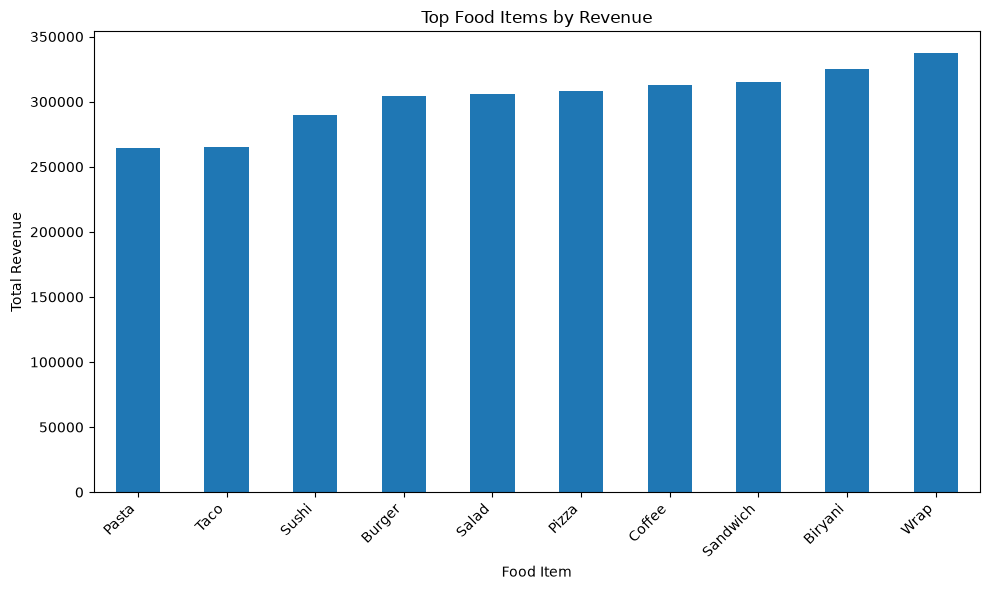

In [44]:
plt.figure(figsize=(10, 6))

food_revenue.sort_values().plot(kind="bar")

plt.title("Top Food Items by Revenue")
plt.xlabel("Food Item")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
restaurant_revenue = (
    df_clean.groupby("Restaurant")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)
print("Restaurant Revenue:")
display(restaurant_revenue)

Restaurant Revenue:


Restaurant
Healthy Bowl     327202.56
Grill Master     316202.87
Veg Express      315967.22
Pizza Point      315815.32
Cafe Delight     302825.20
Sushi Spot       296465.45
Taco Town        292171.78
Biryani House    290586.02
Pasta Place      289554.91
Burger Hub       281625.98
Name: TotalAmount, dtype: float64

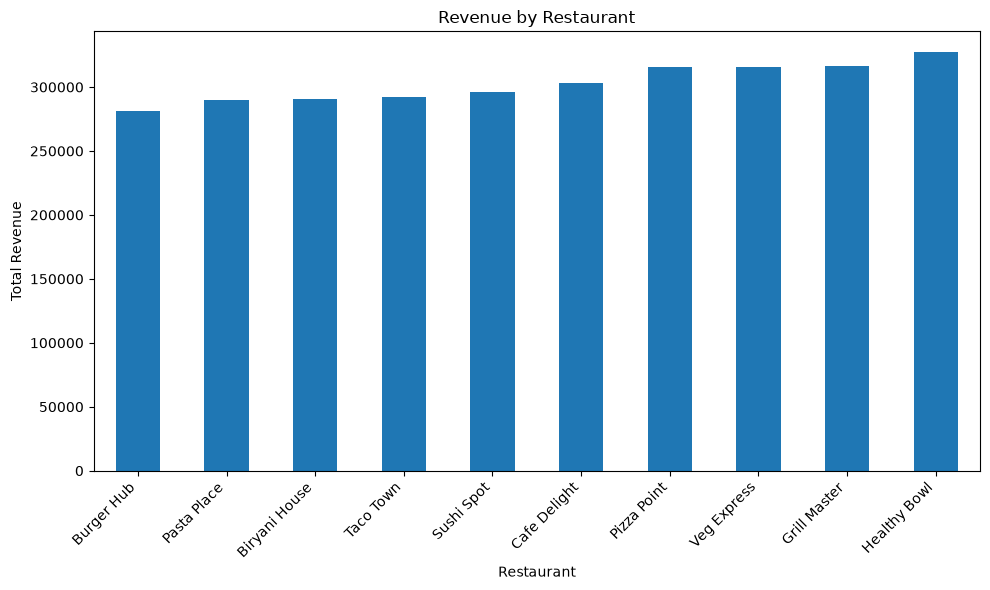

In [46]:
plt.figure(figsize=(10, 6))
restaurant_revenue.sort_values().plot(kind="bar")
plt.title("Revenue by Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
top_5_restaurants = restaurant_revenue.head(5)
print("Top 5 Restaurants by Revenue:")
display(top_5_restaurants)

Top 5 Restaurants by Revenue:


Restaurant
Healthy Bowl    327202.56
Grill Master    316202.87
Veg Express     315967.22
Pizza Point     315815.32
Cafe Delight    302825.20
Name: TotalAmount, dtype: float64

In [48]:
customer_revenue = (
    df_clean.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)
print("Top 10 Customers by Spending:")
display(customer_revenue.head(10))

Top 10 Customers by Spending:


CustomerID
1141    14134.08
1695    13501.95
1595    12656.74
1092    11249.61
1774    10878.03
1792    10851.75
1117    10767.46
1394    10762.00
1403    10651.21
1004    10603.11
Name: TotalAmount, dtype: float64

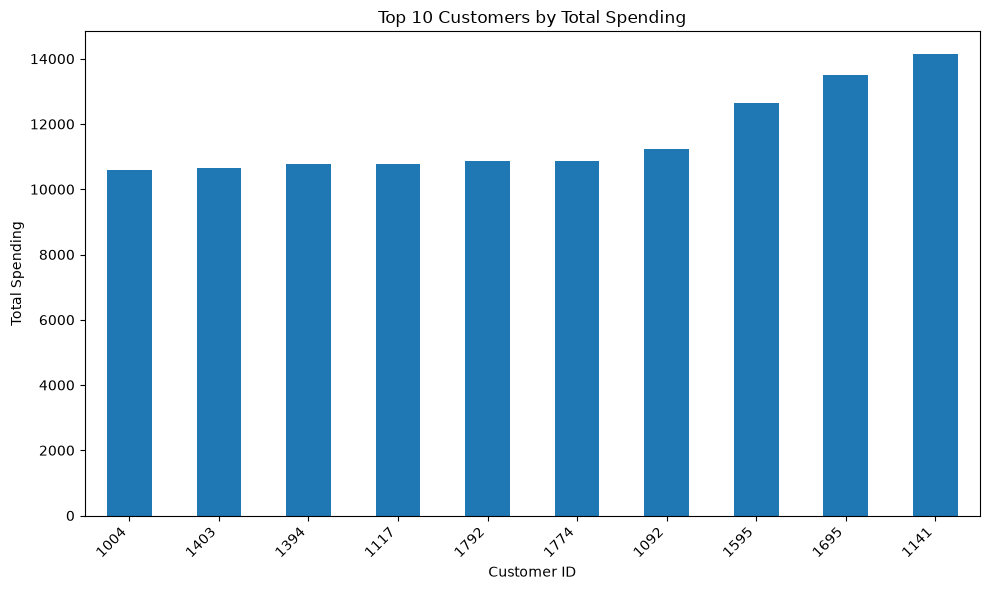

In [49]:
plt.figure(figsize=(10, 6))

customer_revenue.head(10).sort_values().plot(kind="bar")
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [50]:
city_revenue = (
    df_clean.groupby("City")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by City:")
display(city_revenue)

Revenue by City:


City
Delhi        661013.09
Mumbai       611626.51
Hyderabad    606399.53
Chennai      581559.79
Bangalore    567818.39
Name: TotalAmount, dtype: float64

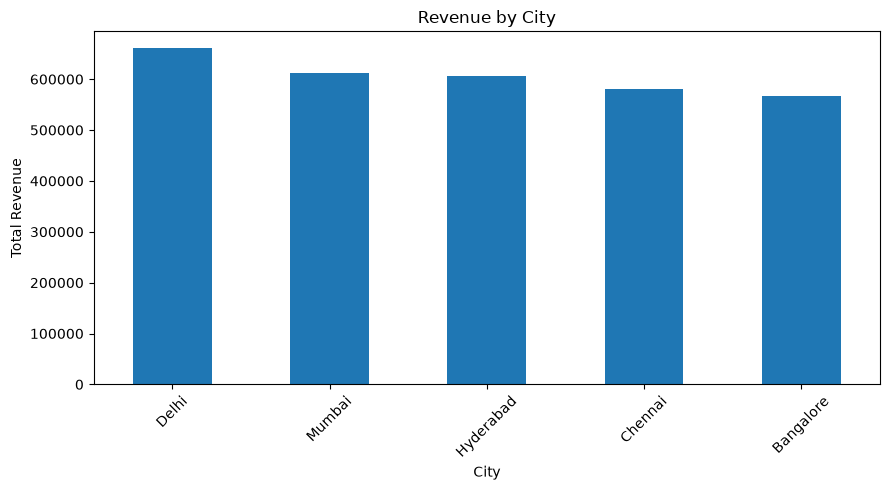

In [51]:
plt.figure(figsize=(9, 5))
city_revenue.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
payment_counts = df_clean["PaymentMethod"].value_counts()
print("Payment Method Distribution:")
display(payment_counts)

Payment Method Distribution:


PaymentMethod
UPI     1050
Cash     987
Card     963
Name: count, dtype: int64

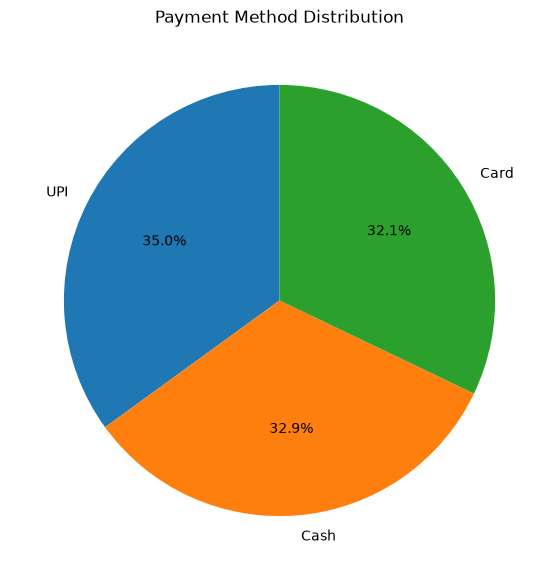

In [53]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")

plt.show()

In [54]:
rating_counts = (
    df_clean["CustomerRating"]
    .value_counts()
    .sort_index()
)

print("Customer Rating Distribution:")
display(rating_counts)

Customer Rating Distribution:


CustomerRating
1    595
2    592
3    605
4    627
5    581
Name: count, dtype: int64

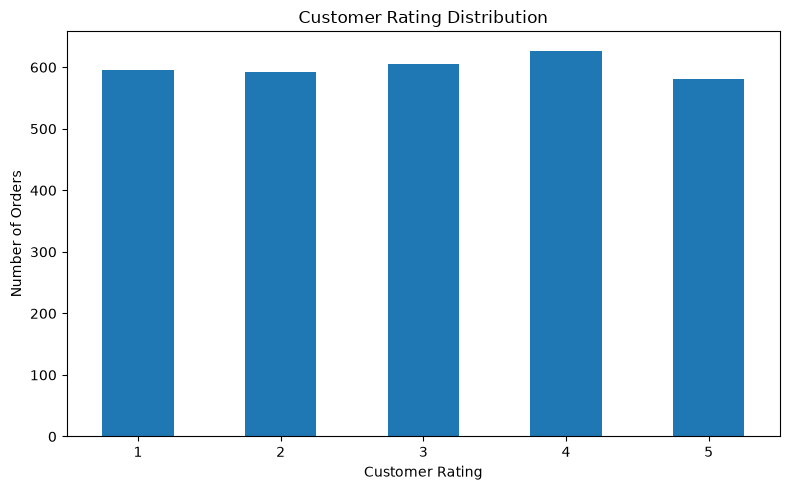

In [55]:
plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [56]:
monthly_revenue = (
    df_clean
    .set_index("OrderDate")
    .resample("ME")["TotalAmount"]
    .sum()
)

print("Monthly Revenue:")
display(monthly_revenue)

Monthly Revenue:


OrderDate
2024-01-31    228733.65
2024-02-29    279640.20
2024-03-31    239471.27
2024-04-30    271320.02
2024-05-31    274833.23
2024-06-30    216166.10
2024-07-31    275629.83
2024-08-31    265599.52
2024-09-30    216775.56
2024-10-31    299625.98
2024-11-30    234365.33
2024-12-31    226256.62
Freq: ME, Name: TotalAmount, dtype: float64

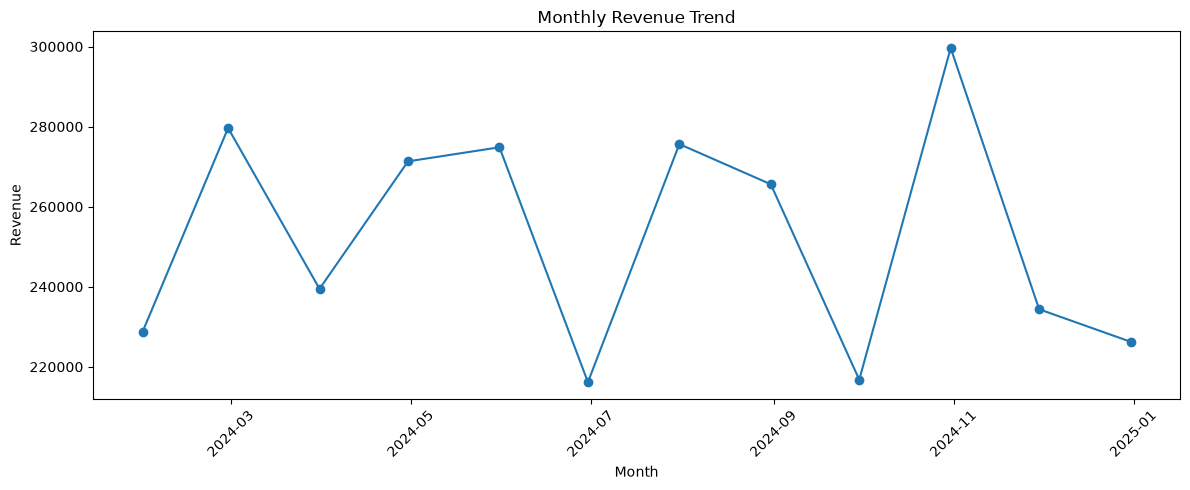

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 4 – Association Rule Learning (Apriori)

In [58]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [59]:
df_clean.groupby("CustomerID")
transactions = (
    df_clean.groupby("CustomerID")["FoodItem"]
    .apply(lambda x: list(set(x)))
    .tolist()
)

print("Number of transactions:", len(transactions))

print("\nFirst 10 customer baskets:")

for transaction in transactions[:10]:
    print(transaction)

Number of transactions: 784

First 10 customer baskets:
['Pasta', 'Coffee']
['Salad']
['Pizza', 'Salad', 'Pasta', 'Burger']
['Sandwich', 'Coffee', 'Biryani', 'Taco', 'Burger']
['Pasta', 'Salad', 'Biryani']
['Sandwich', 'Taco', 'Burger']
['Sandwich', 'Pasta', 'Sushi']
['Wrap', 'Biryani']
['Sandwich', 'Sushi', 'Biryani', 'Burger']
['Sandwich', 'Wrap', 'Sushi']


In [60]:
basket_sizes = [len(transaction) for transaction in transactions]
print("Minimum basket size:", min(basket_sizes))
print("Maximum basket size:", max(basket_sizes))
print("Average basket size:", np.mean(basket_sizes))
print("\nBasket size distribution:")
print(pd.Series(basket_sizes).value_counts().sort_index())

Minimum basket size: 1
Maximum basket size: 8
Average basket size: 3.2091836734693877

Basket size distribution:
1     84
2    182
3    211
4    169
5     87
6     34
7     16
8      1
Name: count, dtype: int64


In [61]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(
    te_array,
    columns=te.columns_
)
basket_df.head()

,Biryani,Burger,Coffee,Pasta,Pizza,Salad,Sandwich,Sushi,Taco,Wrap
0,False,False,True,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False
2,False,True,False,True,True,True,False,False,False,False
3,True,True,True,False,False,False,True,False,True,False
4,True,False,False,True,False,True,False,False,False,False


In [62]:
print("Basket shape:", basket_df.shape)
print("Number of customers:", basket_df.shape[0])
print("Number of food items:", basket_df.shape[1])

Basket shape: (784, 10)
Number of customers: 784
Number of food items: 10


In [63]:
item_frequency = (
    basket_df.sum()
    .sort_values(ascending=False)
)

print("Food Item Frequency:")
display(item_frequency)

Food Item Frequency:


Wrap        282
Biryani     278
Coffee      256
Burger      251
Sandwich    249
Pizza       249
Sushi       249
Salad       244
Taco        233
Pasta       225
dtype: int64

In [64]:
frequent_itemsets = apriori(
    basket_df,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

print("Number of frequent itemsets:",
      len(frequent_itemsets))

display(frequent_itemsets.head(10))

Number of frequent itemsets: 56


,support,itemsets
9,0.359694,frozenset({Wrap})
0,0.354592,frozenset({Biryani})
2,0.326531,frozenset({Coffee})
1,0.320153,frozenset({Burger})
7,0.317602,frozenset({Sushi})
6,0.317602,frozenset({Sandwich})
4,0.317602,frozenset({Pizza})
5,0.311224,frozenset({Salad})
8,0.297194,frozenset({Taco})
3,0.286990,frozenset({Pasta})


In [65]:
frequent_itemsets_display = frequent_itemsets.copy()

frequent_itemsets_display["Itemsets"] = (
    frequent_itemsets_display["itemsets"]
    .apply(lambda x: ", ".join(sorted(x)))
)

frequent_itemsets_display = frequent_itemsets_display[
    ["Itemsets", "support"]
]

display(frequent_itemsets_display.head(10))

,Itemsets,support
9,Wrap,0.359694
0,Biryani,0.354592
2,Coffee,0.326531
1,Burger,0.320153
7,Sushi,0.317602
6,Sandwich,0.317602
4,Pizza,0.317602
5,Salad,0.311224
8,Taco,0.297194
3,Pasta,0.286990


In [66]:
frequent_combinations = frequent_itemsets[
    frequent_itemsets["itemsets"].apply(len) >= 2
].copy()

frequent_combinations["Itemsets"] = (
    frequent_combinations["itemsets"]
    .apply(lambda x: ", ".join(sorted(x)))
)

display(
    frequent_combinations[
        ["Itemsets", "support"]
    ]
.head(10))

,Itemsets,support
18,"Biryani, Wrap",0.130102
15,"Biryani, Sandwich",0.121173
16,"Biryani, Sushi",0.121173
14,"Biryani, Salad",0.118622
33,"Coffee, Wrap",0.118622
11,"Biryani, Coffee",0.117347
26,"Burger, Wrap",0.116071
44,"Pizza, Wrap",0.113520
53,"Sushi, Wrap",0.112245
45,"Salad, Sandwich",0.109694


In [67]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

print("Number of association rules:", len(rules))

Number of association rules: 64


In [68]:
rules_display = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

display(rules_display)

,antecedents,consequents,support,confidence,lift
0,frozenset({Wrap}),frozenset({Biryani}),0.130102,0.361702,1.020052
1,frozenset({Biryani}),frozenset({Wrap}),0.130102,0.366906,1.020052
2,frozenset({Sandwich}),frozenset({Biryani}),0.121173,0.381526,1.075959
3,frozenset({Biryani}),frozenset({Sandwich}),0.121173,0.341727,1.075959
4,frozenset({Sushi}),frozenset({Biryani}),0.121173,0.381526,1.075959
...,...,...,...,...,...
59,frozenset({Pasta}),frozenset({Pizza}),0.088010,0.306667,0.965569
60,frozenset({Pasta}),frozenset({Coffee}),0.086735,0.302222,0.925556
61,"frozenset({Sandwich, Sushi})",frozenset({Biryani}),0.052296,0.476744,1.344487
62,"frozenset({Sandwich, Biryani})",frozenset({Sushi}),0.052296,0.431579,1.358867


In [69]:
rules_display["antecedents"] = (
    rules_display["antecedents"]
    .apply(lambda x: ", ".join(sorted(x)))
)

rules_display["consequents"] = (
    rules_display["consequents"]
    .apply(lambda x: ", ".join(sorted(x)))
)

display(rules_display)

,antecedents,consequents,support,confidence,lift
0,Wrap,Biryani,0.130102,0.361702,1.020052
1,Biryani,Wrap,0.130102,0.366906,1.020052
2,Sandwich,Biryani,0.121173,0.381526,1.075959
3,Biryani,Sandwich,0.121173,0.341727,1.075959
4,Sushi,Biryani,0.121173,0.381526,1.075959
...,...,...,...,...,...
59,Pasta,Pizza,0.088010,0.306667,0.965569
60,Pasta,Coffee,0.086735,0.302222,0.925556
61,"Sandwich, Sushi",Biryani,0.052296,0.476744,1.344487
62,"Biryani, Sandwich",Sushi,0.052296,0.431579,1.358867


In [70]:
rules_by_confidence = rules_display.sort_values(
    by="confidence",
    ascending=False
)

display(rules_by_confidence.head(10))

,antecedents,consequents,support,confidence,lift
61,"Sandwich, Sushi",Biryani,0.052296,0.476744,1.344487
62,"Biryani, Sandwich",Sushi,0.052296,0.431579,1.358867
63,"Biryani, Sushi",Sandwich,0.052296,0.431579,1.358867
2,Sandwich,Biryani,0.121173,0.381526,1.075959
4,Sushi,Biryani,0.121173,0.381526,1.075959
6,Salad,Biryani,0.118622,0.381148,1.074891
1,Biryani,Wrap,0.130102,0.366906,1.020052
8,Coffee,Wrap,0.118622,0.363281,1.009973
13,Burger,Wrap,0.116071,0.362550,1.007940
0,Wrap,Biryani,0.130102,0.361702,1.020052


In [71]:
rules_by_lift = rules_display.sort_values(
    by="lift",
    ascending=False
)

display(rules_by_lift.head(10))

,antecedents,consequents,support,confidence,lift
63,"Biryani, Sushi",Sandwich,0.052296,0.431579,1.358867
62,"Biryani, Sandwich",Sushi,0.052296,0.431579,1.358867
61,"Sandwich, Sushi",Biryani,0.052296,0.476744,1.344487
19,Salad,Sandwich,0.109694,0.352459,1.109750
18,Sandwich,Salad,0.109694,0.345382,1.109750
24,Pizza,Salad,0.108418,0.341365,1.096846
25,Salad,Pizza,0.108418,0.348361,1.096846
20,Sandwich,Sushi,0.109694,0.345382,1.087466
21,Sushi,Sandwich,0.109694,0.345382,1.087466
2,Sandwich,Biryani,0.121173,0.381526,1.075959


In [72]:
useful_rules = rules[
    (rules["confidence"] >= 0.30) &
    (rules["lift"] > 1)
].copy()
useful_rules["antecedents"] = (
    useful_rules["antecedents"]
    .apply(lambda x: ", ".join(sorted(x)))
)

useful_rules["consequents"] = (
    useful_rules["consequents"]
    .apply(lambda x: ", ".join(sorted(x)))
)
useful_rules = useful_rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

In [73]:
display(
    useful_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

,antecedents,consequents,support,confidence,lift
62,"Biryani, Sandwich",Sushi,0.052296,0.431579,1.358867
63,"Biryani, Sushi",Sandwich,0.052296,0.431579,1.358867
61,"Sandwich, Sushi",Biryani,0.052296,0.476744,1.344487
19,Salad,Sandwich,0.109694,0.352459,1.109750
18,Sandwich,Salad,0.109694,0.345382,1.109750
25,Salad,Pizza,0.108418,0.348361,1.096846
24,Pizza,Salad,0.108418,0.341365,1.096846
20,Sandwich,Sushi,0.109694,0.345382,1.087466
21,Sushi,Sandwich,0.109694,0.345382,1.087466
2,Sandwich,Biryani,0.121173,0.381526,1.075959


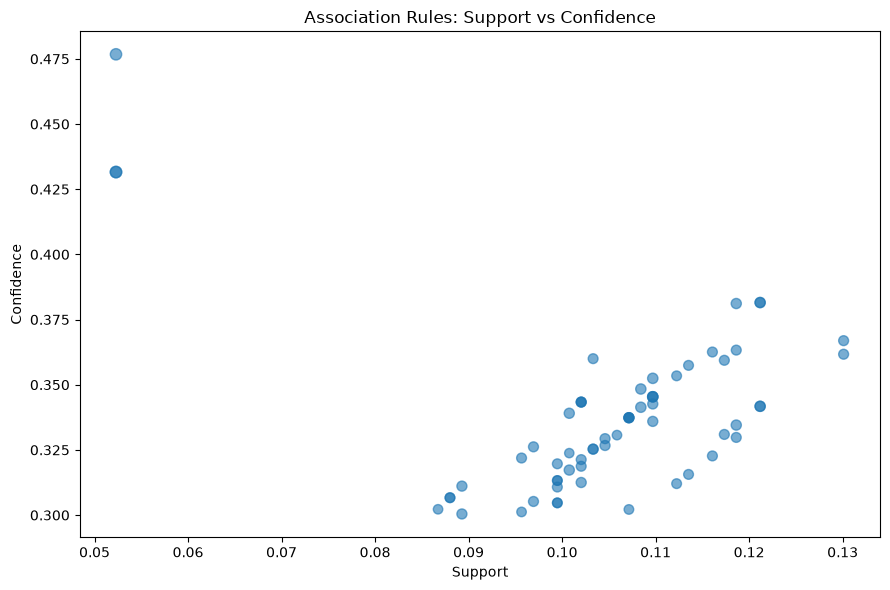

In [74]:
plt.figure(figsize=(9, 6))

plt.scatter(
    rules["support"],
    rules["confidence"],
    s=rules["lift"] * 50,
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs Confidence")

plt.tight_layout()
plt.show()

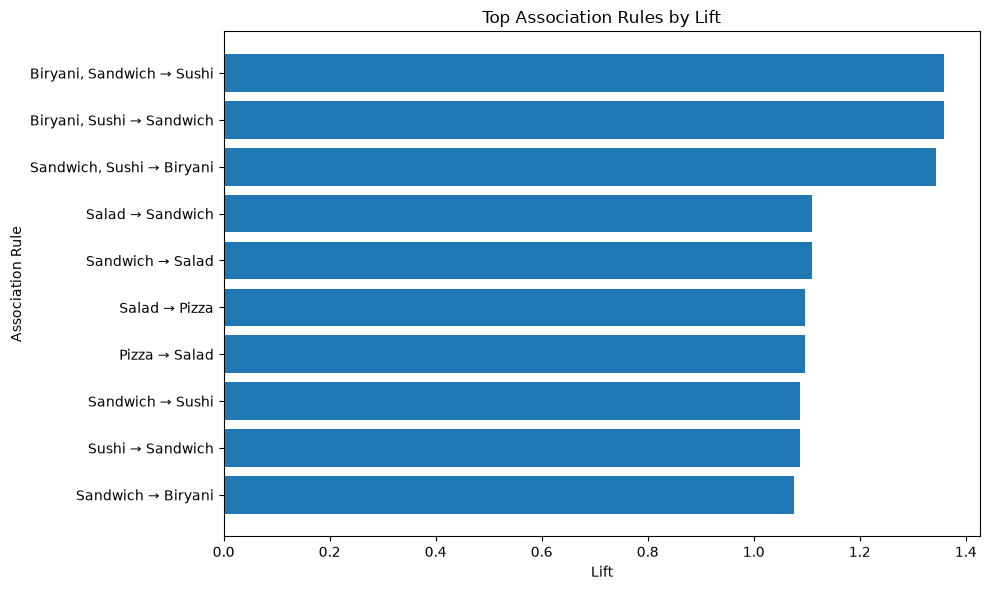

In [75]:
top_lift_rules = useful_rules.head(10).copy()

top_lift_rules["rule"] = (
    top_lift_rules["antecedents"]
    + " → "
    + top_lift_rules["consequents"]
)
plt.figure(figsize=(10, 6))

plt.barh(
    top_lift_rules["rule"][::-1],
    top_lift_rules["lift"][::-1]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top Association Rules by Lift")

plt.tight_layout()
plt.show()

In [76]:
useful_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].to_csv(
    "association_rules.csv",
    index=False
)

print("Association rules saved successfully.")

Association rules saved successfully.


In [77]:
print("Number of customer baskets:", len(transactions))
print("Maximum basket size:", max(basket_sizes))
print("Customers with multiple food items:",
      sum(size > 1 for size in basket_sizes))
print("Frequent itemsets:", len(frequent_itemsets))
print("Association rules:", len(rules))

Number of customer baskets: 784
Maximum basket size: 8
Customers with multiple food items: 700
Frequent itemsets: 56
Association rules: 64


## Task 5 – Recommendation System

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

In [ ]:
recommendation_rules = rules.copy()

recommendation_rules["antecedents"] = (
    recommendation_rules["antecedents"]
    .apply(lambda x: list(x))
)

recommendation_rules["consequents"] = (
    recommendation_rules["consequents"]
    .apply(lambda x: list(x))
)

recommendation_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,[Biryani],[Wrap],0.354592,0.359694,0.130102,0.366906,1.020052,1.0,0.002558,1.011393,0.030458,0.222707,0.011264,0.364304
1,[Wrap],[Biryani],0.359694,0.354592,0.130102,0.361702,1.020052,1.0,0.002558,1.011139,0.030701,0.222707,0.011017,0.364304
2,[Sandwich],[Biryani],0.317602,0.354592,0.121173,0.381526,1.075959,1.0,0.008554,1.043550,0.103453,0.219907,0.041732,0.361626
3,[Biryani],[Sandwich],0.354592,0.317602,0.121173,0.341727,1.075959,1.0,0.008554,1.036648,0.109382,0.219907,0.035353,0.361626
4,[Biryani],[Sushi],0.354592,0.317602,0.121173,0.341727,1.075959,1.0,0.008554,1.036648,0.109382,0.219907,0.035353,0.361626


In [ ]:
def recommend(food_item, rules_df, top_n=5):

    recommendations = []

    for _, row in rules_df.iterrows():

        antecedents = row["antecedents"]
        consequents = row["consequents"]

        if food_item in antecedents:

            for item in consequents:

                if item != food_item:

                    recommendations.append({
                        "FoodItem": item,
                        "Support": row["support"],
                        "Confidence": row["confidence"],
                        "Lift": row["lift"]
                    })

    if not recommendations:
        return pd.DataFrame(
            columns=[
                "FoodItem",
                "Support",
                "Confidence",
                "Lift"
            ]
        )

    recommendations_df = pd.DataFrame(recommendations)

    recommendations_df = (
        recommendations_df
        .sort_values(
            by=["Lift", "Confidence"],
            ascending=False
        )
        .drop_duplicates(
            subset="FoodItem"
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return recommendations_df

In [ ]:
recommend("Pizza", recommendation_rules)

,FoodItem,Support,Confidence,Lift
0,Salad,0.108418,0.341365,1.096846
1,Sushi,0.107143,0.337349,1.062176
2,Sandwich,0.103316,0.325301,1.024242
3,Wrap,0.113520,0.357430,0.993705
4,Coffee,0.099490,0.313253,0.959337


In [ ]:
print("Recommendations for Pizza:")
display(recommend("Pizza", recommendation_rules))

print("\nRecommendations for Burger:")
display(recommend("Burger", recommendation_rules))

print("\nRecommendations for Wrap:")
display(recommend("Wrap", recommendation_rules))

Recommendations for Pizza:


,FoodItem,Support,Confidence,Lift
0,Salad,0.108418,0.341365,1.096846
1,Sushi,0.107143,0.337349,1.062176
2,Sandwich,0.103316,0.325301,1.024242
3,Wrap,0.113520,0.357430,0.993705
4,Coffee,0.099490,0.313253,0.959337



Recommendations for Burger:


,FoodItem,Support,Confidence,Lift
0,Coffee,0.109694,0.342629,1.049303
1,Sandwich,0.104592,0.326693,1.028624
2,Wrap,0.116071,0.362550,1.007940
3,Sushi,0.102041,0.318725,1.003536
4,Salad,0.099490,0.310757,0.998498



Recommendations for Wrap:


,FoodItem,Support,Confidence,Lift
0,Biryani,0.130102,0.361702,1.020052
1,Coffee,0.118622,0.329787,1.009973
2,Burger,0.116071,0.322695,1.007940
3,Pizza,0.113520,0.315603,0.993705
4,Sushi,0.112245,0.312057,0.982540


In [ ]:
def get_recommendations(food_item, rules_df, top_n=5):
    
    result = recommend(
        food_item,
        rules_df,
        top_n
    )
    
    return result["FoodItem"].tolist()
get_recommendations("Pizza", recommendation_rules)

['Salad', 'Sushi', 'Sandwich', 'Wrap', 'Coffee']

In [ ]:
def get_recommendations(food_item, rules_df, top_n=5):
    
    food_item = food_item.strip()
    
    result = recommend(
        food_item,
        rules_df,
        top_n
    )
    
    if result.empty:
        return []
    
    return result["FoodItem"].tolist()
get_recommendations("Chocolate", recommendation_rules)

[]

In [ ]:
food_item_mapping = {
    item.lower(): item
    for item in df_clean["FoodItem"].unique()
}
def get_recommendations(food_item, rules_df, top_n=5):
    
    food_item = food_item.strip().lower()
    if food_item not in food_item_mapping:
        return []
    
    actual_food_item = food_item_mapping[food_item]
    
    result = recommend(
        actual_food_item,
        rules_df,
        top_n
    )
    
    if result.empty:
        return []
    
    return result["FoodItem"].tolist()
print(food_item_mapping)

{'pizza': 'Pizza', 'wrap': 'Wrap', 'salad': 'Salad', 'taco': 'Taco', 'sandwich': 'Sandwich', 'biryani': 'Biryani', 'sushi': 'Sushi', 'burger': 'Burger', 'coffee': 'Coffee', 'pasta': 'Pasta'}


In [ ]:
print(get_recommendations("PIZZA", recommendation_rules))

['Salad', 'Sushi', 'Sandwich', 'Wrap', 'Coffee']


In [ ]:
all_food_items = sorted(
    df_clean["FoodItem"].unique()
)

recommendation_report = []

for food in all_food_items:
    
    recommendations = get_recommendations(
        food,
        recommendation_rules,
        top_n=5
    )
    
    recommendation_report.append({
        "FoodItem": food,
        "Recommendations": ", ".join(recommendations)
    })

recommendation_report = pd.DataFrame(
    recommendation_report
)

display(recommendation_report)

,FoodItem,Recommendations
0,Biryani,"Sushi, Sandwich, Salad, Wrap, Coffee"
1,Burger,"Coffee, Sandwich, Wrap, Sushi, Salad"
2,Coffee,"Taco, Burger, Biryani, Wrap, Sushi"
3,Pasta,"Taco, Wrap, Salad, Pizza, Coffee"
4,Pizza,"Salad, Sushi, Sandwich, Wrap, Coffee"
5,Salad,"Sandwich, Pizza, Biryani, Burger, Wrap"
6,Sandwich,"Sushi, Biryani, Salad, Burger, Taco"
7,Sushi,"Sandwich, Biryani, Taco, Pizza, Burger"
8,Taco,"Sushi, Coffee, Pasta, Sandwich, Burger"
9,Wrap,"Biryani, Coffee, Burger, Pizza, Sushi"


In [ ]:
recommendation_report.to_csv(
    "recommendations.csv",
    index=False
)
print("Recommendation report saved successfully.")

Recommendation report saved successfully.


In [ ]:
food = "Pizza"

recommendations = recommend(
    food,
    recommendation_rules,
    top_n=5
)

display(recommendations)

,FoodItem,Support,Confidence,Lift
0,Salad,0.108418,0.341365,1.096846
1,Sushi,0.107143,0.337349,1.062176
2,Sandwich,0.103316,0.325301,1.024242
3,Wrap,0.113520,0.357430,0.993705
4,Coffee,0.099490,0.313253,0.959337


In [ ]:
def recommend_with_details(food_item, rules_df, top_n=5):

    food_item = food_item.strip()

    recommendations = []

    for _, row in rules_df.iterrows():

        antecedents = row["antecedents"]
        consequents = row["consequents"]

        # Check whether the requested food is in the antecedent
        if food_item in antecedents:

            for item in consequents:

                if item != food_item:

                    recommendations.append({
                        "Recommended Item": item,
                        "Support": row["support"],
                        "Confidence": row["confidence"],
                        "Lift": row["lift"]
                    })

    # No recommendations found
    if not recommendations:

        print(
            f"No recommendations found for '{food_item}'."
        )

        return pd.DataFrame(
            columns=[
                "Recommended Item",
                "Support",
                "Confidence",
                "Lift"
            ]
        )

    result = pd.DataFrame(recommendations)

    # Sort using the ACTUAL column names
    result = (
        result
        .sort_values(
            by=["Lift", "Confidence"],
            ascending=False
        )
        .drop_duplicates(
            subset="Recommended Item"
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return result

In [ ]:
recommend_with_details(
    "Pizza",
    recommendation_rules,
    top_n=5
)

,Recommended Item,Support,Confidence,Lift
0,Salad,0.108418,0.341365,1.096846
1,Sushi,0.107143,0.337349,1.062176
2,Sandwich,0.103316,0.325301,1.024242
3,Wrap,0.113520,0.357430,0.993705
4,Coffee,0.099490,0.313253,0.959337


## Task 6 – Time Series Forecasting

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print(df_clean["OrderDate"].dtype)

datetime64[us]


In [ ]:
monthly_sales = (
    df_clean
    .set_index("OrderDate")
    .resample("ME")["TotalAmount"]
    .sum()
)

print("Monthly Sales:")
display(monthly_sales)

Monthly Sales:


OrderDate
2024-01-31    228733.65
2024-02-29    279640.20
2024-03-31    239471.27
2024-04-30    271320.02
2024-05-31    274833.23
2024-06-30    216166.10
2024-07-31    275629.83
2024-08-31    265599.52
2024-09-30    216775.56
2024-10-31    299625.98
2024-11-30    234365.33
2024-12-31    226256.62
Freq: ME, Name: TotalAmount, dtype: float64

In [ ]:
print("Number of months:", len(monthly_sales))
print("Start date:", monthly_sales.index.min())
print("End date:", monthly_sales.index.max())

Number of months: 12
Start date: 2024-01-31 00:00:00
End date: 2024-12-31 00:00:00


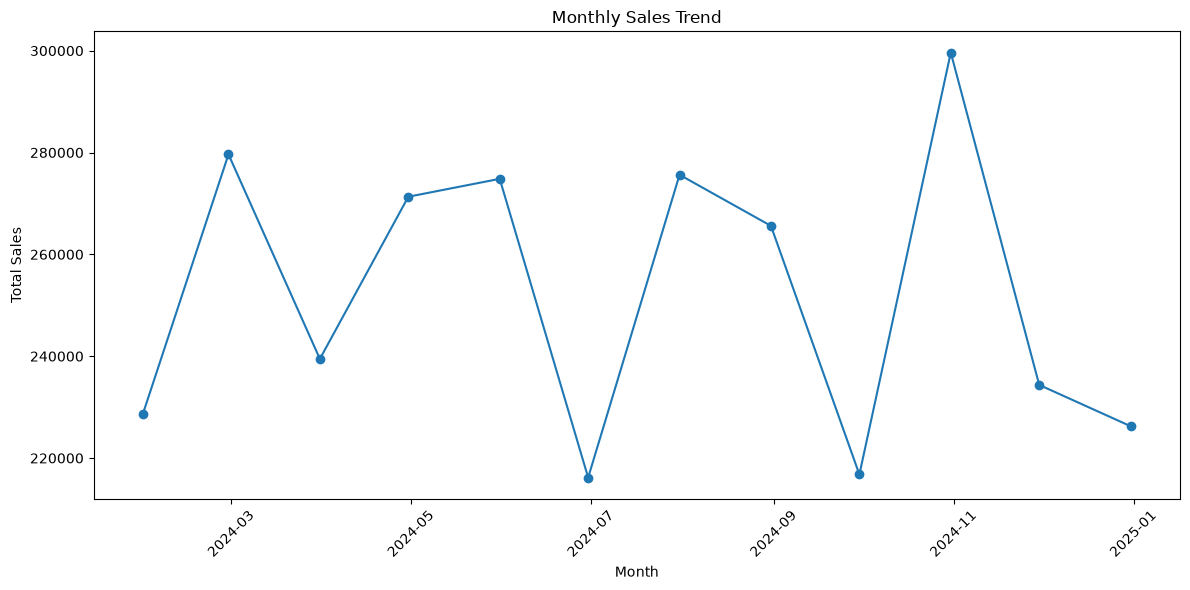

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_orders = (
    df_clean
    .set_index("OrderDate")
    .resample("ME")["OrderID"]
    .nunique()
)

print("Monthly Orders:")
display(monthly_orders)

Monthly Orders:


OrderDate
2024-01-31    240
2024-02-29    255
2024-03-31    250
2024-04-30    257
2024-05-31    271
2024-06-30    217
2024-07-31    276
2024-08-31    266
2024-09-30    224
2024-10-31    285
2024-11-30    240
2024-12-31    219
Freq: ME, Name: OrderID, dtype: int64

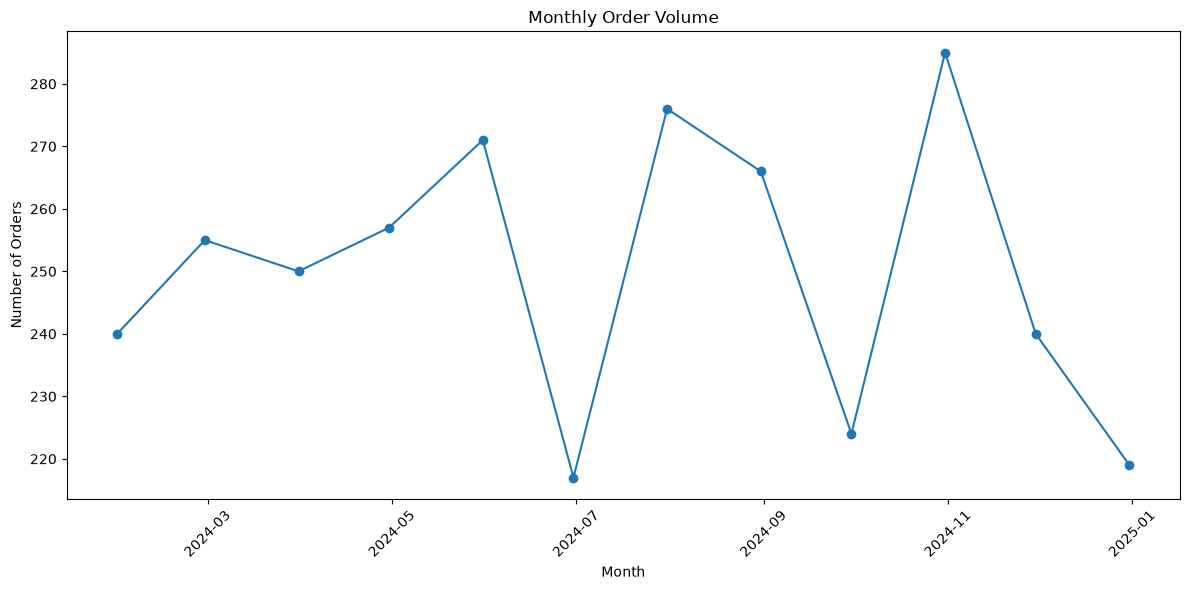

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_aov = (
    df_clean
    .set_index("OrderDate")
    .resample("ME")["TotalAmount"]
    .mean()
)

display(monthly_aov)

OrderDate
2024-01-31     953.056875
2024-02-29    1096.628235
2024-03-31     957.885080
2024-04-30    1055.719922
2024-05-31    1014.144760
2024-06-30     996.157143
2024-07-31     998.658804
2024-08-31     998.494436
2024-09-30     967.748036
2024-10-31    1051.319228
2024-11-30     976.522208
2024-12-31    1033.135251
Freq: ME, Name: TotalAmount, dtype: float64

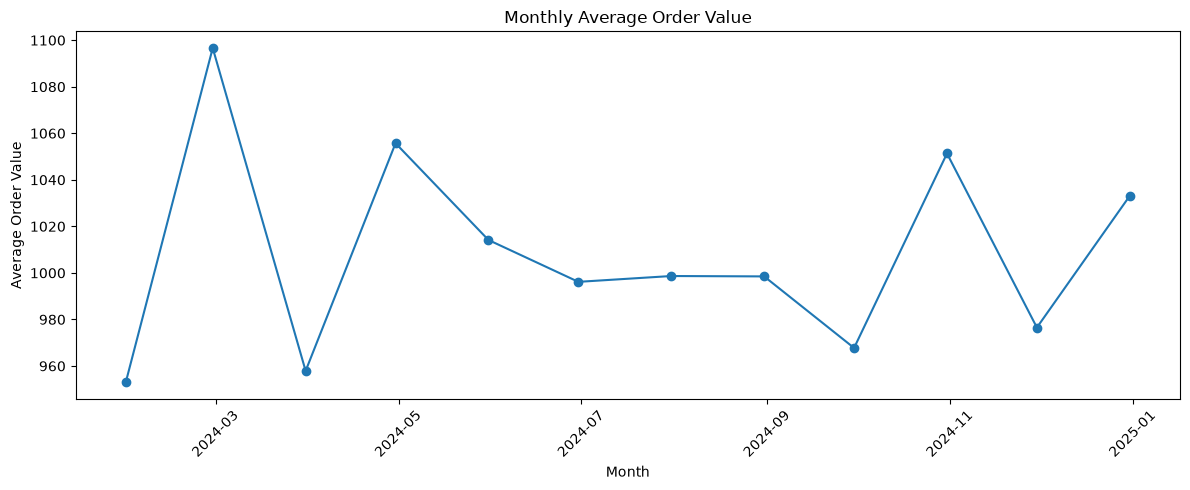

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_aov.index,
    monthly_aov.values,
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_seasonality = (
    df_clean
    .assign(CalendarMonth=df_clean["OrderDate"].dt.month)
    .groupby("CalendarMonth")["TotalAmount"]
    .sum()
)

display(monthly_seasonality)

CalendarMonth
1     228733.65
2     279640.20
3     239471.27
4     271320.02
5     274833.23
6     216166.10
7     275629.83
8     265599.52
9     216775.56
10    299625.98
11    234365.33
12    226256.62
Name: TotalAmount, dtype: float64

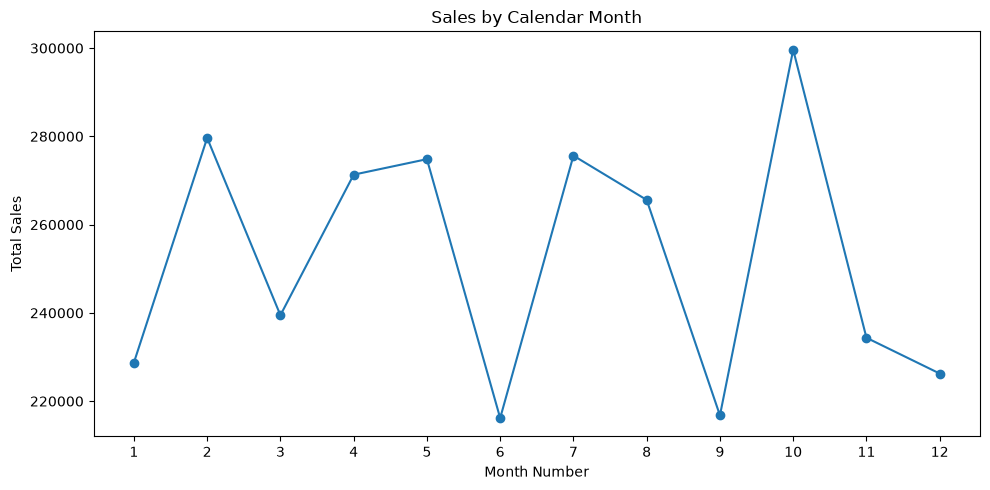

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Sales by Calendar Month")
plt.xlabel("Month Number")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(monthly_sales)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.31921076911583
p-value: 0.0004113889623326428


C:\Users\Acer\AppData\Local\Temp\ipykernel_19356\2361881168.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(monthly_sales)


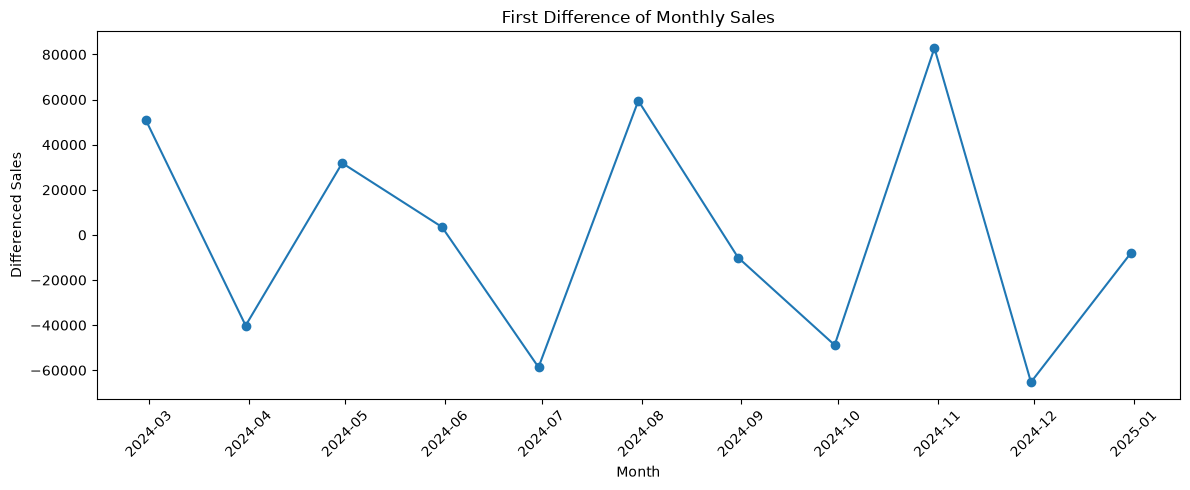

In [ ]:
sales_diff = monthly_sales.diff().dropna()
plt.figure(figsize=(12, 5))

plt.plot(
    sales_diff.index,
    sales_diff.values,
    marker="o"
)

plt.title("First Difference of Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Differenced Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
model = ARIMA(
    monthly_sales,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            TotalAmount   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -134.455
Date:                Sat, 03 Oct 2026   AIC                            274.910
Time:                        13:38:07   BIC                            276.104
Sample:                    01-31-2024   HQIC                           274.158
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2908      1.892      0.154      0.878      -3.418       4.000
ma.L1         -0.3743      1.901     -0.197      0.844      -4.101       3.352
sigma2      1.718e+09   1.71e-10      1e+19      0.0

In [ ]:
fitted_values = model_fit.fittedvalues

display(fitted_values)

OrderDate
2024-01-31         0.000000
2024-02-29    210298.412251
2024-03-31    268518.505276
2024-04-30    238659.906683
2024-05-31    268358.156363
2024-06-30    273431.407675
2024-07-31    220538.397476
2024-08-31    272302.834636
2024-09-30    265191.514587
2024-10-31    220698.220063
2024-11-30    294178.587807
2024-12-31    237773.808358
Freq: ME, dtype: float64

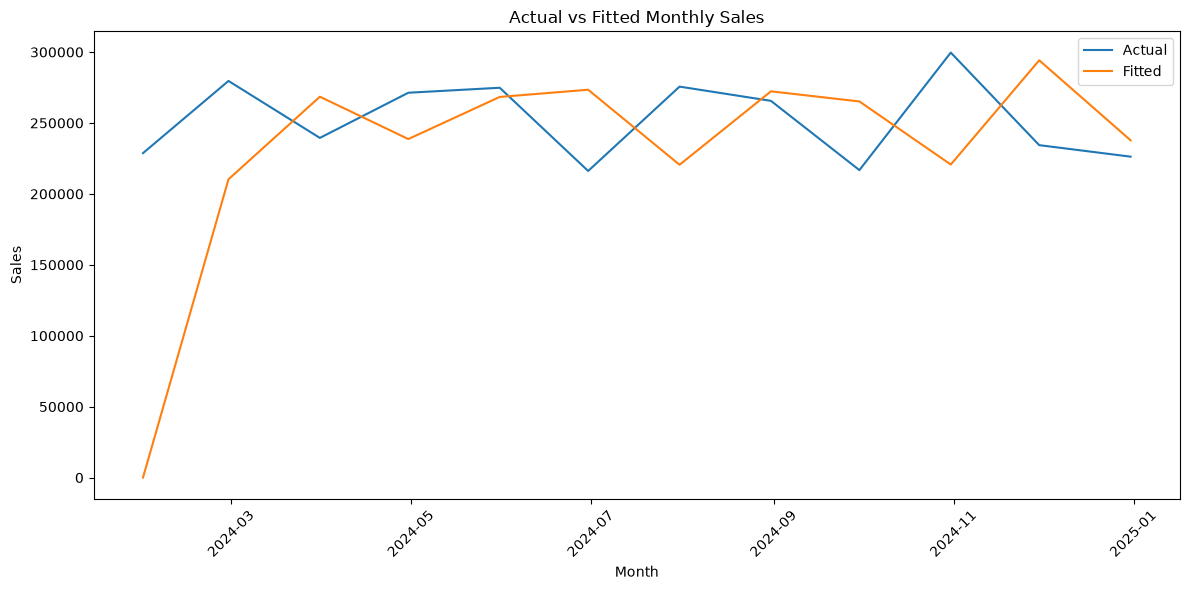

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Actual"
)

plt.plot(
    fitted_values.index,
    fitted_values.values,
    label="Fitted"
)

plt.title("Actual vs Fitted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
forecast_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

forecast_df = pd.DataFrame({
    "Month": forecast_dates,
    "Forecasted_Sales": forecast.values
})

display(forecast_df)

,Month,Forecasted_Sales
0,2025-01-31,228209.199908
1,2025-02-28,228777.036854
2,2025-03-31,228942.171605


In [ ]:
forecast_df.to_csv(
    "forecast_results.csv",
    index=False
)

print("Forecast results saved successfully.")

Forecast results saved successfully.


In [ ]:
latest_sales = monthly_sales.iloc[-1]
next_month_forecast = forecast_df["Forecasted_Sales"].iloc[0]

growth_percentage = (
    (next_month_forecast - latest_sales)
    / latest_sales
) * 100

print(f"Latest actual monthly sales: {latest_sales:.2f}")
print(f"Next month forecast: {next_month_forecast:.2f}")
print(f"Change: {growth_percentage:.2f}%")

Latest actual monthly sales: 226256.62
Next month forecast: 228209.20
Change: 0.86%


In [ ]:
print("Number of monthly observations:", len(monthly_sales))
print("\nARIMA Model:")
print(model_fit.summary())

print("\n3-Month Forecast:")
display(forecast_df)

Number of monthly observations: 12

ARIMA Model:
                               SARIMAX Results                                
Dep. Variable:            TotalAmount   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -134.455
Date:                Sat, 03 Oct 2026   AIC                            274.910
Time:                        13:41:20   BIC                            276.104
Sample:                    01-31-2024   HQIC                           274.158
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2908      1.892      0.154      0.878      -3.418       4.000
ma.L1         -0.3743      1.901     -0.197      0.844      -4.101       3.352
sig

,Month,Forecasted_Sales
0,2025-01-31,228209.199908
1,2025-02-28,228777.036854
2,2025-03-31,228942.171605
